# Compare Daughter-specific genes for three models

**Goal:**
Show how the different config changes affect the daughter-specific genes (reported by Guo, 2011). How much overlap is there in determining which genes are considered "daughter-specific" expression?

**Models:**
1. CG1, DG1 - Can do this now with the previous results
2. Delta-DG1 - Should be able to do tomororw when the runs end
3. Single G1 (will have no daughter-specific genes) - Don't believe we will need to do this.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
from src.config import load_combined_yl_alpha_vst_gene_expression_config
from src.delta_config import load_delta_combined_gene_expression_config
from src.model import Model

cg1_config = load_combined_yl_alpha_vst_gene_expression_config()
delta_config = load_delta_combined_gene_expression_config()

gene_name = 'DSE1'
cg1_model = Model(cg1_config, gene_name)
delta_model = Model(delta_config, gene_name)


In [8]:
cg1_model.deconvolve_find_optimal_gamma()
delta_model.deconvolve_find_optimal_gamma()


In [120]:
from src.timer import Timer
from src.geneset import guo_ds_genes

d_genes = guo_ds_genes()
n = len(d_genes)

cg1_fs = np.zeros((n, cg1_model.H.shape[1]))
delta_fs = np.zeros((n, delta_model.H.shape[1]))
timer = Timer()

for i in range(n):
    
    if i % 10 == 0:
        timer.print_time(f"{i}/{n}")

    # Setup models
    orf_name = d_genes[i]
    cg1_model = Model(cg1_config, orf_name)
    delta_model = Model(delta_config, orf_name)

    # Deconvolve
    cg1_model.deconvolve_find_optimal_gamma()
    delta_model.deconvolve_find_optimal_gamma()

    cg1_fs[i] = cg1_model.f
    delta_fs[i] = delta_model.f


In [132]:

def get_daughter_specific_genes(d_genes, config, fs):
    c_i = config.get_Hpositions_for_phase('CG1')
    d_i = config.get_Hpositions_for_phase('DG1')

    n = len(fs)
    d_genes_indices = np.arange(n)[fs[:, c_i].max(axis=1) < fs[:, d_i].max(axis=1)]
    return d_genes[d_genes_indices], d_genes_indices

delta_ds_genes, delta_ds_i = get_daughter_specific_genes(d_genes, delta_config, delta_fs)
cg1_ds_genes, cg1_ds_i = get_daughter_specific_genes(d_genes, cg1_config, cg1_fs)


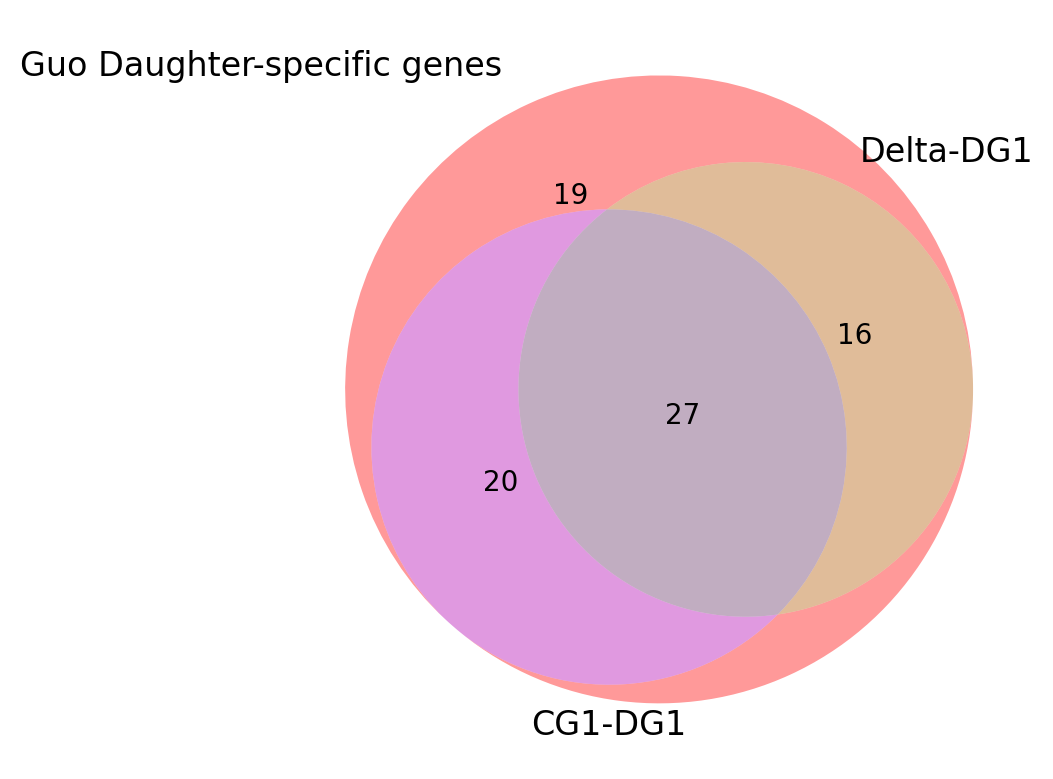

In [138]:
from matplotlib_venn import venn3

set1 = set(d_genes)
set2 = set(delta_ds_genes)
set3 = set(cg1_ds_genes)

venn3([set1, set2, set3], ('Guo Daughter-specific genes', 'Delta-DG1', 'CG1-DG1'))

plt.show()

In [203]:
def plot_f_genes(config, fs, normalize=True, title=None):
    
    c_i = config.get_Hpositions_for_phase('CG1')
    d_i = config.get_Hpositions_for_phase('DG1')
    postg1_i = config.get_Hpositions_for_phase('postG1')
    
    # normalize fs by max and min
    non_rg1_indices = fs[:, np.concatenate([c_i, d_i, postg1_i])]
    min_val, max_val = non_rg1_indices.min(axis=1), non_rg1_indices.max(axis=1)
    diff_vals = max_val-min_val
    
    def normalize_min_max(fs):
        if not normalize: return fs
        return (fs-min_val.reshape((-1, 1))) / (diff_vals.reshape((-1, 1))+1e-5)

    c_fs = normalize_min_max(fs[:, c_i])
    d_fs = normalize_min_max(fs[:, d_i])
    p_fs = normalize_min_max(fs[:, postg1_i])
    n = len(fs)

    plt.figure(figsize=(9, 3))
    plt.subplot(1, 3, 1)
    plt.plot(c_fs.T, alpha=0.75)
    plt.title("CG1")
    plt.ylim(0, max_val.max()*1.1)
        
    plt.subplot(1, 3, 2)
    plt.plot(d_fs.T, alpha=0.75)
    plt.title("DG1")
    plt.ylim(0, max_val.max()*1.1)
    
    plt.subplot(1, 3, 3)
    plt.plot(p_fs.T, alpha=0.75)
    plt.title("Post-G1")
    plt.ylim(0, max_val.max()*1.1)

    plt.suptitle(title + f", n={n}", fontsize=13)
    plt.subplots_adjust(top=0.8)

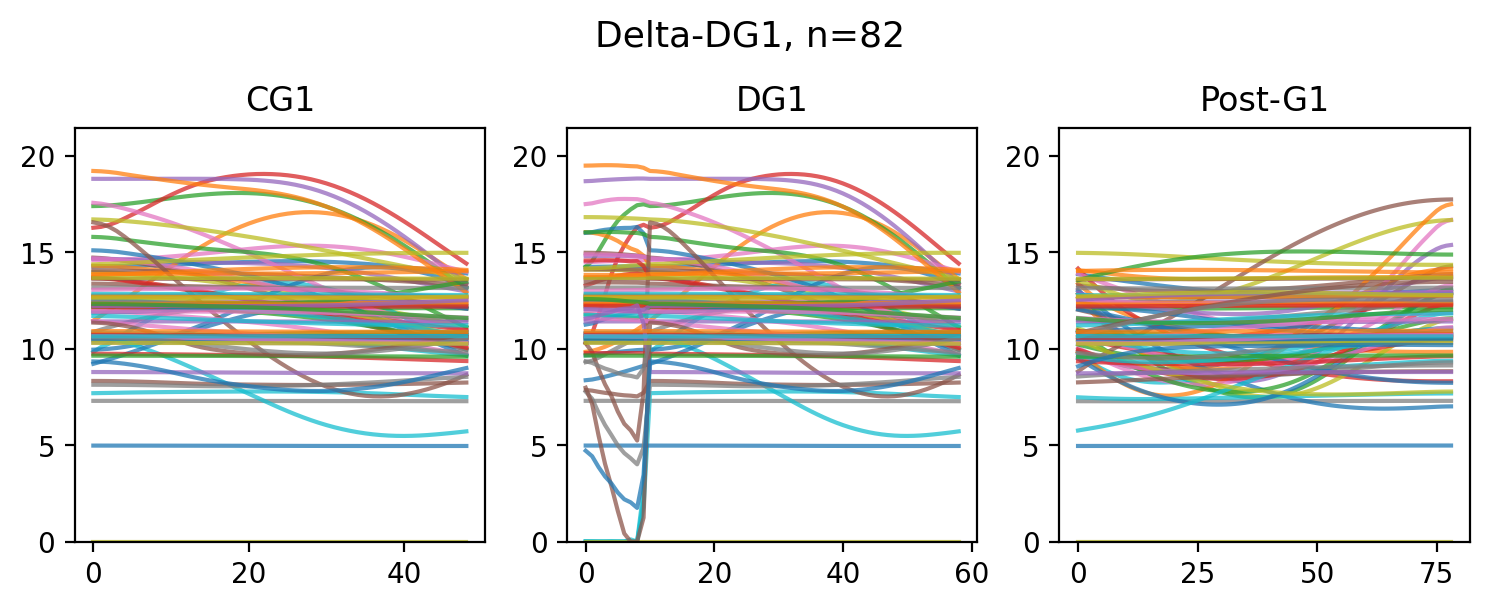

In [204]:
plot_f_genes(delta_config, delta_fs, normalize=False, title="Delta-DG1")

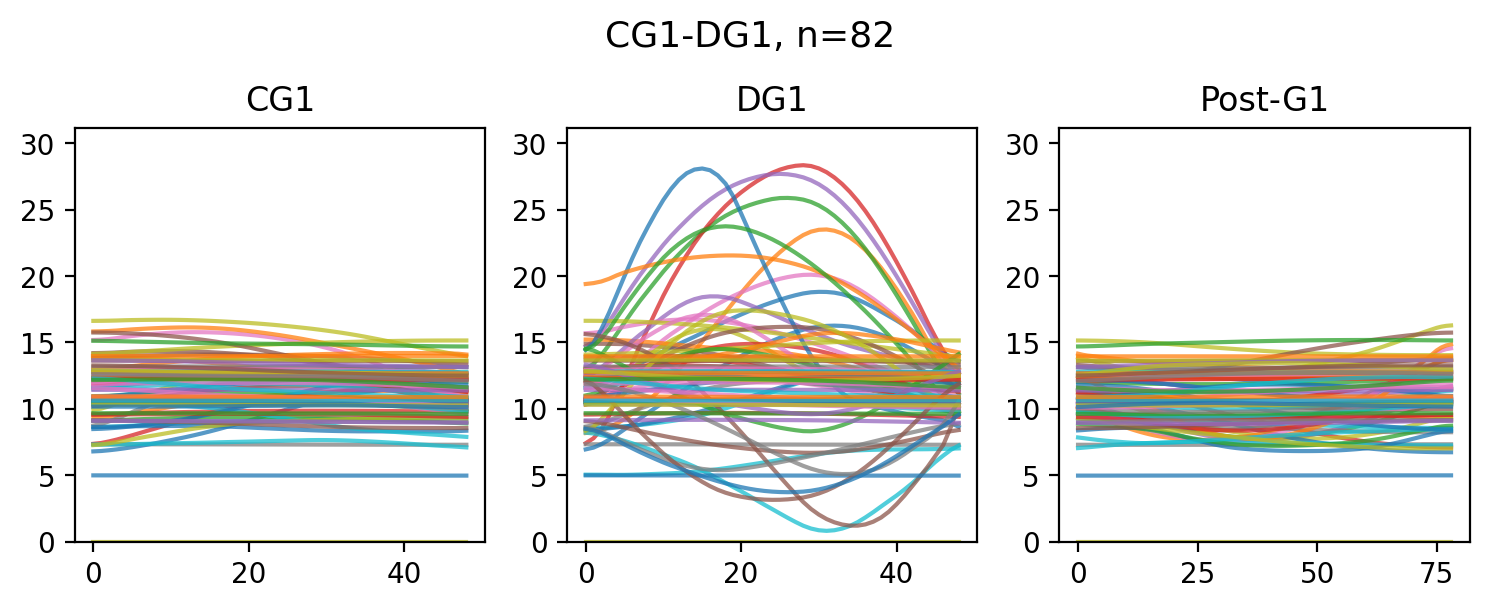

In [205]:
plot_f_genes(cg1_config, cg1_fs, normalize=False, title="CG1-DG1")

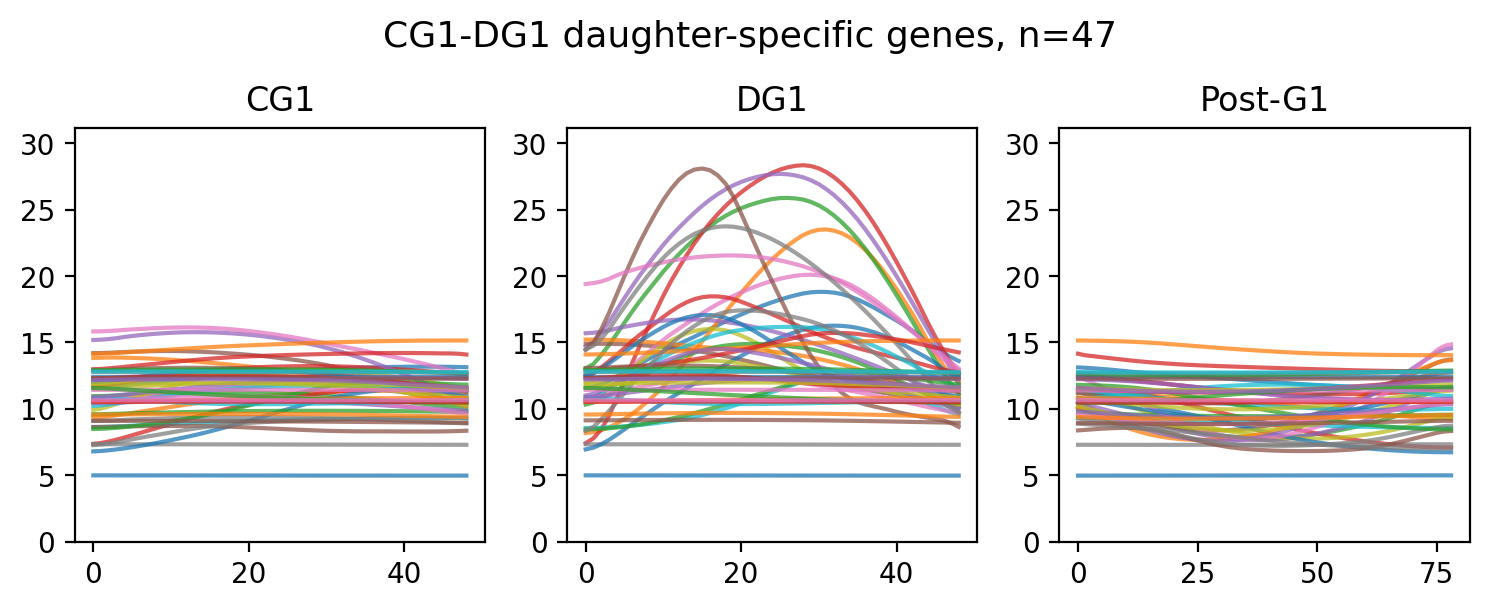

In [206]:
plot_f_genes(cg1_config, cg1_fs[cg1_d_indices], normalize=False, title="CG1-DG1 daughter-specific genes")

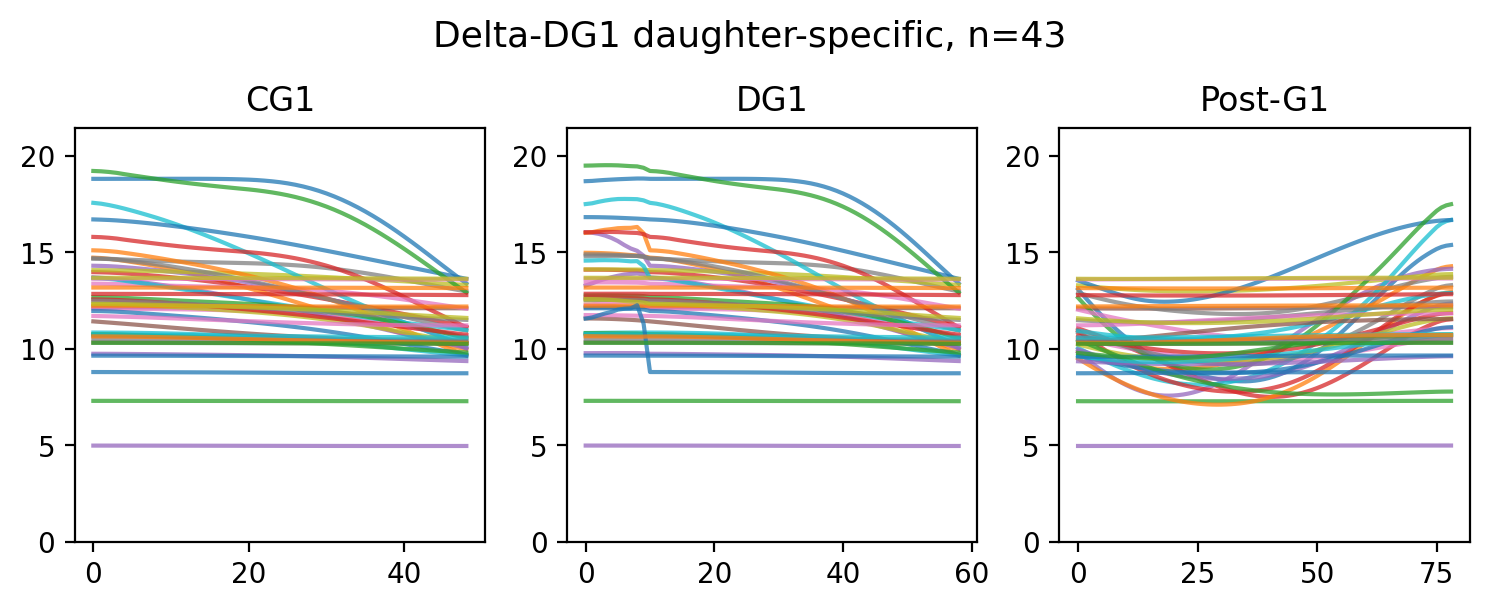

In [208]:
plot_f_genes(delta_config, delta_fs[delta_d_indices], normalize=False, title="Delta-DG1 daughter-specific")